# Mundiales 2018, 2022 y 2026
## Preparación de datos y entrada al análisis supervisado

Trabajaremos exclusivamente con la fase de grupos. Los archivos contienen errores deliberados. No uses la base del profesor.

## Objetivos

- Perfilar datos.
- Estandarizar esquemas.
- Limpiar fechas, equipos, goles y marcadores.
- Eliminar duplicados con criterio.
- Comparar torneos mediante tasas.
- Construir variables conocidas antes de cada partido.
- Entrenar un primer clasificador y detectar fuga de información.

In [4]:
from pathlib import Path
import re
import unicodedata
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

DATA = Path('./datos')
pd.set_option('display.max_columns', 50)

## Cargar los tres archivos

In [5]:
d18 = pd.read_csv(DATA / 'mundial_2018_sucio.csv', dtype=str)
d22 = pd.read_csv(DATA / 'mundial_2022_sucio.csv', dtype=str)
d26 = pd.read_csv(DATA / 'mundial_2026_sucio.csv', dtype=str)

for nombre, df in [('2018', d18), ('2022', d22), ('2026', d26)]:
    print(f'--- {nombre} ---', df.shape)
    display(df.head(3))


--- 2018 --- (50, 16)


,ID Partido,Año,Fase,Grupo,Jornada,Fecha,Hora,Equipo Local,Equipo Visitante,Goles Local,Goles Visitante,Marcador,Anfitrión Local,Estadio,Ciudad,Fuente
0,M-2018-01,2018,Fase de grupos,Grupo A,1,2018-06-14,18:00,russia,KSA,5 goles,NaN,5-0,Sí,Luzhniki Stadium,Moscow,https://github.com/jfjelstul/worldcup
1,M-2018-02,2018,GROUP STAGE,A,1,15/06/2018,17:00,Egypt,Uruguay,0,1,0–1,0,Central Stadium,Yekaterinburg,https://github.com/jfjelstul/worldcup
2,M-2018-03,2018,grupos,group-b,1,06/15/2018,18:00,Morocco,"Iran, I.R.",0,1,0 : 1,FALSE,Krestovsky Stadium,Saint Petersburg,https://github.com/jfjelstul/worldcup


--- 2022 --- (51, 16)


,match_id,WorldCup,stage,group_name,match_day,date,local,visitor,home_score,away_score,score_text,home_host,venue,city_name,comentario,source_url
0,M-2022-01,2022,group,Group A,1,2022-11-20,Qatar,Ecuador,NaN,2,0 : 2,1,Al Bayt Stadium,Al Khor,ok,https://github.com/jfjelstul/worldcup
1,M-2022-02,2022,Group Stage,B,1,21/11/2022,England,IR Iran,6,2,6 x 2,FALSE,Khalifa International Stadium,Al Rayyan,NaN,https://github.com/jfjelstul/worldcup
2,M-2022-03,2022,Fase grupos,Grupo A,1,11/21/2022,Senegal,Netherlands,0,2,0—2,no,Al Thumama Stadium,Doha,revisar,https://github.com/jfjelstul/worldcup


--- 2026 --- (75, 14)


,match,wc,round,grp,md,played_on,home,away,HG,AG,result_raw,host_h,host_a,source
0,M-2026-001,2026,GS,A,1,2026-06-11,México,South Africa,NaN,s/d,2–0,TRUE,no,https://en.wikipedia.org/wiki/2026_FIFA_World_...
1,M-2026-002,2026,group stage,Grupo A,1,12/06/2026,Korea Rep.,Czech Republic,2,1,2 : 1,no,No,https://en.wikipedia.org/wiki/2026_FIFA_World_...
2,M-2026-007,2026,fase de grupos,group-b,1,06/12/2026,Canada,BOSNIA & HERZEGOVINA,1,1,1 x 1,Sí,0,https://en.wikipedia.org/wiki/2026_FIFA_World_...


## Perfilado

Para cada archivo revisa:

- columnas;
- tipos;
- valores nulos;
- duplicados;
- valores únicos de grupos, fases y equipos;
- goles que no puedan convertirse directamente a número.

In [6]:
def perfil(df, nombre):
    print(f'=== Perfil {nombre} ===')
    print('Filas x columnas:', df.shape)
    print('Columnas:', df.columns.tolist())
    print()
    print('Valores nulos por columna:')
    print(df.isna().sum())
    print()
    id_col = df.columns[0]
    print(f'Duplicados por {id_col}:', df.duplicated(subset=[id_col]).sum())
    print()
    for col in df.columns:
        if col.lower() in ('grupo', 'group_name', 'grp', 'fase', 'stage', 'round'):
            print(f'Valores únicos de {col}:', sorted(df[col].dropna().unique().tolist()))
    print()
    for col in df.columns:
        if 'goles' in col.lower() or col in ('home_score','away_score','HG','AG'):
            no_numerico = df[col].dropna()
            no_numerico = no_numerico[~no_numerico.str.match(r'^-?\d+$')]
            print(f'{col}: valores que no son enteros directos:', no_numerico.unique().tolist())
    print('=' * 50)

perfil(d18, '2018')
perfil(d22, '2022')
perfil(d26, '2026')


=== Perfil 2018 ===
Filas x columnas: (50, 16)
Columnas: ['ID Partido', 'Año', 'Fase', 'Grupo', 'Jornada', 'Fecha', 'Hora', 'Equipo Local', 'Equipo Visitante', 'Goles Local', 'Goles Visitante', 'Marcador', 'Anfitrión Local', 'Estadio', 'Ciudad', 'Fuente']

Valores nulos por columna:
ID Partido          0
Año                 0
Fase                0
Grupo               1
Jornada             0
Fecha               0
Hora                0
Equipo Local        0
Equipo Visitante    0
Goles Local         0
Goles Visitante     3
Marcador            1
Anfitrión Local     0
Estadio             0
Ciudad              0
Fuente              0
dtype: int64

Duplicados por ID Partido: 2

Valores únicos de Fase: ['1ra fase', 'Fase de grupos', 'GROUP STAGE', 'grupos']
Valores únicos de Grupo: ['A ', 'B ', 'C ', 'D ', 'E ', 'F ', 'G ', 'Grupo A', 'Grupo B', 'Grupo C', 'Grupo D', 'Grupo E', 'Grupo F', 'Grupo G', 'Grupo H', 'group-a', 'group-b', 'group-c', 'group-d', 'group-e', 'group-f', 'group-g', 'group-

## Unificar nombres de columnas

In [7]:
rename_maps = {
    2018: {
        'ID Partido': 'partido_id', 'Año': 'mundial', 'Fase': 'fase', 'Grupo': 'grupo',
        'Jornada': 'jornada', 'Fecha': 'fecha', 'Equipo Local': 'equipo_local',
        'Equipo Visitante': 'equipo_visitante', 'Goles Local': 'goles_local',
        'Goles Visitante': 'goles_visitante', 'Marcador': 'marcador',
        'Anfitrión Local': 'local_es_anfitrion', 'Fuente': 'fuente',
    },
    2022: {
        'match_id': 'partido_id', 'WorldCup': 'mundial', 'stage': 'fase', 'group_name': 'grupo',
        'match_day': 'jornada', 'date': 'fecha', 'local': 'equipo_local', 'visitor': 'equipo_visitante',
        'home_score': 'goles_local', 'away_score': 'goles_visitante', 'score_text': 'marcador',
        'home_host': 'local_es_anfitrion', 'source_url': 'fuente',
    },
    2026: {
        'match': 'partido_id', 'wc': 'mundial', 'round': 'fase', 'grp': 'grupo', 'md': 'jornada',
        'played_on': 'fecha', 'home': 'equipo_local', 'away': 'equipo_visitante', 'HG': 'goles_local',
        'AG': 'goles_visitante', 'result_raw': 'marcador', 'host_h': 'local_es_anfitrion',
        'host_a': 'visitante_es_anfitrion', 'source': 'fuente',
    },
}

# Esquema canónico mínimo:
columnas_base = [
    'partido_id', 'mundial', 'fase', 'grupo', 'jornada', 'fecha',
    'equipo_local', 'equipo_visitante', 'goles_local',
    'goles_visitante', 'marcador', 'local_es_anfitrion',
    'visitante_es_anfitrion', 'fuente'
]

# Nota: 2018 y 2022 no traen columna de anfitrión del visitante porque
# tuvieron un único país sede (Rusia y Qatar); ese caso se resuelve en
# limpiar_mundial() creando la columna con valor False.


## Normalizar equipos

No conviene borrar acentos del nombre que se mostrará. Crea una clave auxiliar sin acentos, minúscula y sin signos para buscar en el catálogo.

In [8]:
catalogo = pd.read_csv(DATA / 'catalogo_equipos.csv')

def clave_texto(valor):
    """Normaliza texto para comparar: sin acentos, minúsculas, sin guiones/puntos."""
    if pd.isna(valor):
        return None
    s = str(valor).strip()
    s = unicodedata.normalize('NFKD', s).encode('ascii', 'ignore').decode()
    s = re.sub(r'[\s\-_.]+', ' ', s).strip().lower()
    return s

mapa_equipos = {clave_texto(r['variante']): r['nombre_canonico'].strip() for _, r in catalogo.iterrows()}

def equipo_canonico(valor):
    k = clave_texto(valor)
    if k in mapa_equipos:
        return mapa_equipos[k]
    # si no está en el catálogo, se conserva el valor original (recortado) para poder detectarlo
    return str(valor).strip()

# Prueba rápida
for t in ['russia', 'KSA', 'Deutschland', 'the netherlands', 'CURACAO', 'Cote d Ivoire']:
    print(t, '->', equipo_canonico(t))


russia -> Russia
KSA -> Saudi Arabia
Deutschland -> Germany
the netherlands -> Netherlands
CURACAO -> Curacao
Cote d Ivoire -> Ivory Coast


## Fechas, grupos, booleanos y marcadores

In [9]:
rangos = {
    2018: ('2018-06-14', '2018-06-28'),
    2022: ('2022-11-20', '2022-12-02'),
    2026: ('2026-06-11', '2026-06-27'),
}

MESES = {'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5, 'jun': 6, 'jul': 7,
         'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12}

def convertir_fecha(valor, mundial):
    """Reconoce ISO, DD/MM/AAAA, MM/DD/AAAA, DD-MM-AA, 'Mon DD, AAAA' y seriales de Excel.
    Cuando DD/MM y MM/DD son ambiguos (ambos <=12), se elige la interpretación
    que caiga dentro del rango de fechas real del torneo."""
    if pd.isna(valor) or str(valor).strip().upper() in ('N/D', 'S/D', ''):
        return pd.NaT
    s = str(valor).strip()

    if re.match(r'^\d{5}$', s):  # serial de Excel (días desde 1899-12-30)
        base = pd.Timestamp('1899-12-30')
        return base + pd.Timedelta(days=int(s))

    m = re.match(r'^(\d{4})-(\d{2})-(\d{2})$', s)
    if m:
        return pd.Timestamp(year=int(m.group(1)), month=int(m.group(2)), day=int(m.group(3)))

    m = re.match(r'^([A-Za-z]{3})\s+(\d{1,2}),\s*(\d{4})$', s)
    if m:
        return pd.Timestamp(year=int(m.group(3)), month=MESES[m.group(1).lower()], day=int(m.group(2)))

    m = re.match(r'^(\d{1,2})/(\d{1,2})/(\d{4})$', s)
    if m:
        a, b, y = int(m.group(1)), int(m.group(2)), int(m.group(3))
        candidatos = []
        for (dd, mm) in [(a, b), (b, a)]:
            try:
                f = pd.Timestamp(year=y, month=mm, day=dd)
                if pd.Timestamp(rangos[mundial][0]) <= f <= pd.Timestamp(rangos[mundial][1]):
                    candidatos.append(f)
            except ValueError:
                continue
        return candidatos[0] if candidatos else pd.NaT

    m = re.match(r'^(\d{2})-(\d{2})-(\d{2})$', s)
    if m:
        d, mo, y = int(m.group(1)), int(m.group(2)), int(m.group(3))
        return pd.Timestamp(year=2000 + y, month=mo, day=d)

    return pd.NaT

def extraer_numero(valor):
    """Devuelve el primer entero encontrado en el texto, o NaN."""
    if pd.isna(valor):
        return np.nan
    s = str(valor).strip()
    if clave_texto(s) in ('s d', 'n d', 'na', 'n a', ''):
        return np.nan
    m = re.search(r'-?\d+', s)
    return int(m.group()) if m else np.nan

def separar_marcador(valor):
    """Acepta separadores -, –, —, :, x o X y devuelve (goles_local, goles_visitante)."""
    if pd.isna(valor):
        return np.nan, np.nan
    s = str(valor).strip()
    if clave_texto(s) in ('s d', 'n d', ''):
        return np.nan, np.nan
    for simbolo in ['–', '—', ':', ' x ', 'x', 'X', '-']:
        s = s.replace(simbolo, '@')
    nums = re.findall(r'\d+', s)
    if len(nums) != 2:
        return np.nan, np.nan
    return int(nums[0]), int(nums[1])

def normalizar_grupo(valor):
    """Extrae una letra A-L del texto de grupo, sin importar el formato de entrada."""
    if pd.isna(valor):
        return np.nan
    s = str(valor).strip()
    if clave_texto(s) in ('s d', 'n d', ''):
        return np.nan
    s2 = re.sub(r'(?i)(grupo|group|grp|stage|-)', ' ', s).strip()
    letras = re.findall(r'[A-La-l]', s2)
    return letras[0].upper() if letras else np.nan

def normalizar_booleano(valor):
    """Reconoce Sí/Si/TRUE/1/yes (insensible a mayúsculas) como verdadero."""
    if pd.isna(valor):
        return False
    s = str(valor).strip().lower()
    return s in ('si', 'sí', 'true', '1', 'yes')

# Pruebas rápidas
print(convertir_fecha('15/06/2018', 2018), convertir_fecha('06/15/2018', 2018), convertir_fecha('46187', 2026))
print(separar_marcador('0–1'), separar_marcador('2 x 1'), separar_marcador('3 : 3'))
print(normalizar_grupo('group-b'), normalizar_grupo('Grupo A'), normalizar_grupo('GROUP STAGE'))


2018-06-15 00:00:00 2018-06-15 00:00:00 2026-06-14 00:00:00
(0, 1) (2, 1) (3, 3)
B A nan


## Función de limpieza reproducible

In [10]:
def limpiar_mundial(df, mundial):
    df = df.rename(columns=rename_maps[mundial]).copy()
    for col in columnas_base:
        if col not in df.columns:
            df[col] = np.nan

    # quitar filas sin id y duplicados exactos (se conserva la primera aparición)
    df = df.dropna(subset=['partido_id']).reset_index(drop=True)
    df = df.drop_duplicates(subset='partido_id', keep='first').reset_index(drop=True)

    df['mundial'] = mundial
    df['fase'] = 'Fase de grupos'
    df['jornada'] = df['jornada'].astype(int)
    df['equipo_local'] = df['equipo_local'].apply(equipo_canonico)
    df['equipo_visitante'] = df['equipo_visitante'].apply(equipo_canonico)
    df['grupo'] = df['grupo'].apply(normalizar_grupo)
    df['fecha'] = df['fecha'].apply(lambda v: convertir_fecha(v, mundial))
    df['local_es_anfitrion'] = df['local_es_anfitrion'].apply(normalizar_booleano)
    df['visitante_es_anfitrion'] = df['visitante_es_anfitrion'].apply(normalizar_booleano)

    # --- reparar goles: regla del Paso 7 de la guía ---
    # 1) si el marcador es interpretable y no negativo, se usa para reparar goles vacíos.
    # 2) si el marcador está vacío/no interpretable, se usan los goles separados.
    # 3) si ambos existen y coinciden, se usan; si no coinciden, se prioriza el marcador.
    # 4) ningún partido válido puede tener goles negativos.
    gl_sep = df['goles_local'].apply(extraer_numero)
    gv_sep = df['goles_visitante'].apply(extraer_numero)
    marcador_split = df['marcador'].apply(separar_marcador)
    gl_mk = marcador_split.apply(lambda t: t[0])
    gv_mk = marcador_split.apply(lambda t: t[1])

    gl_final, gv_final = [], []
    for i in range(len(df)):
        a_ok = pd.notna(gl_sep[i]) and pd.notna(gv_sep[i]) and gl_sep[i] >= 0 and gv_sep[i] >= 0
        b_ok = pd.notna(gl_mk[i]) and pd.notna(gv_mk[i]) and gl_mk[i] >= 0 and gv_mk[i] >= 0
        if b_ok:
            gl_final.append(gl_mk[i]); gv_final.append(gv_mk[i])
        elif a_ok:
            gl_final.append(gl_sep[i]); gv_final.append(gv_sep[i])
        else:
            gl_final.append(np.nan); gv_final.append(np.nan)
    df['goles_local'] = gl_final
    df['goles_visitante'] = gv_final
    df['marcador'] = df.apply(
        lambda r: f"{int(r['goles_local'])}-{int(r['goles_visitante'])}" if pd.notna(r['goles_local']) else np.nan,
        axis=1)

    # --- inferir grupos faltantes: cada equipo pertenece a un único grupo del torneo ---
    equipo_grupo = {}
    for _, r in df.iterrows():
        if pd.notna(r['grupo']):
            equipo_grupo.setdefault(r['equipo_local'], []).append(r['grupo'])
            equipo_grupo.setdefault(r['equipo_visitante'], []).append(r['grupo'])

    def grupo_mas_comun(equipo):
        c = Counter(equipo_grupo.get(equipo, []))
        return c.most_common(1)[0][0] if c else np.nan

    for idx in df[df['grupo'].isna()].index:
        g = grupo_mas_comun(df.at[idx, 'equipo_local'])
        if pd.isna(g):
            g = grupo_mas_comun(df.at[idx, 'equipo_visitante'])
        df.at[idx, 'grupo'] = g

    # --- inferir fechas faltantes con la moda del mismo grupo+jornada ---
    for idx in df[df['fecha'].isna()].index:
        mismo = df[(df['grupo'] == df.at[idx, 'grupo']) &
                   (df['jornada'] == df.at[idx, 'jornada']) & df['fecha'].notna()]
        if len(mismo):
            df.at[idx, 'fecha'] = mismo['fecha'].mode().iloc[0]

    # --- columnas derivadas ---
    df['resultado_local'] = np.where(df['goles_local'] > df['goles_visitante'], 'Gana',
                              np.where(df['goles_local'] == df['goles_visitante'], 'Empata', 'Pierde'))
    df['goles_totales'] = df['goles_local'] + df['goles_visitante']
    df['diferencia_goles'] = df['goles_local'] - df['goles_visitante']
    df['puntos_local'] = np.where(df['resultado_local'] == 'Gana', 3,
                                   np.where(df['resultado_local'] == 'Empata', 1, 0))
    df['puntos_visitante'] = np.where(df['resultado_local'] == 'Pierde', 3,
                                       np.where(df['resultado_local'] == 'Empata', 1, 0))

    columnas_finales = columnas_base + ['resultado_local', 'goles_totales', 'diferencia_goles',
                                         'puntos_local', 'puntos_visitante']
    return df[columnas_finales]

limpio18 = limpiar_mundial(d18, 2018)
limpio22 = limpiar_mundial(d22, 2022)
limpio26 = limpiar_mundial(d26, 2026)
partidos = pd.concat([limpio18, limpio22, limpio26], ignore_index=True)
print(partidos.shape)
partidos.head()


(168, 19)


,partido_id,mundial,fase,grupo,jornada,fecha,equipo_local,equipo_visitante,goles_local,goles_visitante,marcador,local_es_anfitrion,visitante_es_anfitrion,fuente,resultado_local,goles_totales,diferencia_goles,puntos_local,puntos_visitante
0,M-2018-01,2018,Fase de grupos,A,1,2018-06-14,Russia,Saudi Arabia,5.0,0.0,5-0,True,False,https://github.com/jfjelstul/worldcup,Gana,5.0,5.0,3,0
1,M-2018-02,2018,Fase de grupos,A,1,2018-06-15,Egypt,Uruguay,0.0,1.0,0-1,False,False,https://github.com/jfjelstul/worldcup,Pierde,1.0,-1.0,0,3
2,M-2018-03,2018,Fase de grupos,B,1,2018-06-15,Morocco,Iran,0.0,1.0,0-1,False,False,https://github.com/jfjelstul/worldcup,Pierde,1.0,-1.0,0,3
3,M-2018-04,2018,Fase de grupos,B,1,2018-06-15,Portugal,Spain,3.0,3.0,3-3,False,False,https://github.com/jfjelstul/worldcup,Empata,6.0,0.0,1,1
4,M-2018-05,2018,Fase de grupos,C,1,2018-06-16,France,Australia,2.0,1.0,2-1,False,False,https://github.com/jfjelstul/worldcup,Gana,3.0,1.0,3,0


## Validaciones obligatorias

La limpieza no termina cuando el código deja de producir errores. Debes comprobar invariantes.

In [11]:
conteo = partidos.groupby('mundial').size()
assert conteo.get(2018) == 48, f'2018 tiene {conteo.get(2018)} partidos, se esperaban 48'
assert conteo.get(2022) == 48, f'2022 tiene {conteo.get(2022)} partidos, se esperaban 48'
assert conteo.get(2026) == 72, f'2026 tiene {conteo.get(2026)} partidos, se esperaban 72'

assert partidos['partido_id'].duplicated().sum() == 0, 'hay partido_id duplicados'
assert (partidos['goles_local'] >= 0).all() and (partidos['goles_visitante'] >= 0).all(), 'hay goles negativos'

criticos = ['equipo_local', 'equipo_visitante', 'goles_local', 'goles_visitante', 'grupo']
assert partidos[criticos].isna().sum().sum() == 0, 'hay nulos en columnas críticas'

marcador_calc = (partidos['goles_local'].astype(int).astype(str) + '-' +
                  partidos['goles_visitante'].astype(int).astype(str))
assert (partidos['marcador'] == marcador_calc).all(), 'marcador inconsistente con los goles'

assert len(partidos) == partidos['partido_id'].nunique(), 'hay más de una fila por partido'

print('Todas las validaciones pasaron: 168 partidos limpios (48 + 48 + 72).')


Todas las validaciones pasaron: 168 partidos limpios (48 + 48 + 72).


## Comparación de los Mundiales

,mundial,partidos_jugados,goles,empates,goles_por_partido,porcentaje_empates
0,2018,48,122.0,9,2.541667,0.187500
1,2022,48,120.0,10,2.500000,0.208333
2,2026,72,215.0,20,2.986111,0.277778


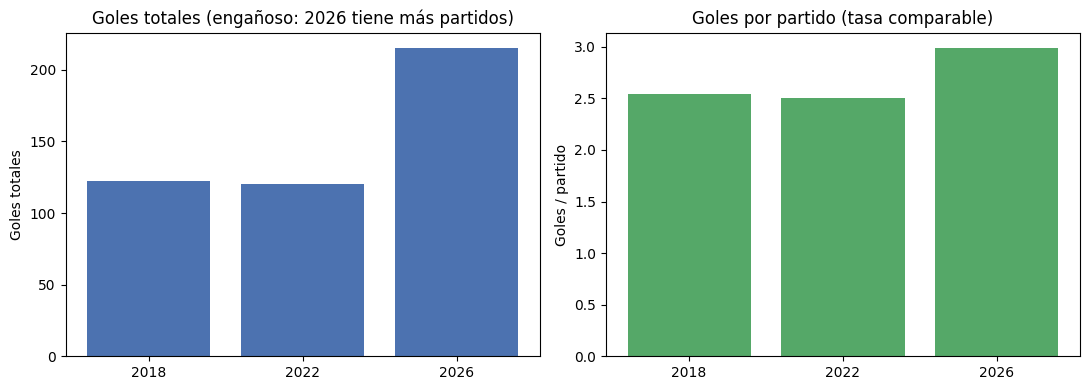

In [12]:
comparacion = partidos.groupby('mundial').agg(
    partidos_jugados=('partido_id', 'count'),
    goles=('goles_totales', 'sum'),
    empates=('resultado_local', lambda s: (s == 'Empata').sum()),
).reset_index()
comparacion['goles_por_partido'] = comparacion['goles'] / comparacion['partidos_jugados']
comparacion['porcentaje_empates'] = comparacion['empates'] / comparacion['partidos_jugados']
display(comparacion)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(comparacion['mundial'].astype(str), comparacion['goles'], color='#4C72B0')
axes[0].set_title('Goles totales (engañoso: 2026 tiene más partidos)')
axes[0].set_ylabel('Goles totales')

axes[1].bar(comparacion['mundial'].astype(str), comparacion['goles_por_partido'], color='#55A868')
axes[1].set_title('Goles por partido (tasa comparable)')
axes[1].set_ylabel('Goles / partido')
plt.tight_layout()
plt.show()


## Tabla por equipo

In [13]:
locales = partidos[['mundial', 'equipo_local', 'goles_local', 'goles_visitante', 'puntos_local']].rename(
    columns={'equipo_local': 'equipo', 'goles_local': 'gf', 'goles_visitante': 'gc', 'puntos_local': 'pts'})
visitantes = partidos[['mundial', 'equipo_visitante', 'goles_visitante', 'goles_local', 'puntos_visitante']].rename(
    columns={'equipo_visitante': 'equipo', 'goles_visitante': 'gf', 'goles_local': 'gc', 'puntos_visitante': 'pts'})
apariciones = pd.concat([locales, visitantes], ignore_index=True)

apariciones['pg'] = (apariciones['pts'] == 3).astype(int)
apariciones['pe'] = (apariciones['pts'] == 1).astype(int)
apariciones['pp'] = (apariciones['pts'] == 0).astype(int)

tabla_equipos = apariciones.groupby(['mundial', 'equipo']).agg(
    pj=('pts', 'count'), pg=('pg', 'sum'), pe=('pe', 'sum'), pp=('pp', 'sum'),
    gf=('gf', 'sum'), gc=('gc', 'sum'), pts=('pts', 'sum')
).reset_index()
tabla_equipos['dg'] = tabla_equipos['gf'] - tabla_equipos['gc']
tabla_equipos['pts_por_partido'] = tabla_equipos['pts'] / tabla_equipos['pj']

print('Filas esperadas: 32 (2018) + 32 (2022) + 48 (2026) =', 32 + 32 + 48)
print('Filas obtenidas:', len(tabla_equipos))
tabla_equipos.sort_values(['mundial', 'pts', 'dg'], ascending=[True, False, False]).groupby('mundial').head(5)


Filas esperadas: 32 (2018) + 32 (2022) + 48 (2026) = 112
Filas obtenidas: 112


,mundial,equipo,pj,pg,pe,pp,gf,gc,pts,dg,pts_por_partido
2,2018,Belgium,3,3,0,0,9.0,2.0,9,7.0,3.000000
6,2018,Croatia,3,3,0,0,7.0,1.0,9,6.0,3.000000
31,2018,Uruguay,3,3,0,0,5.0,0.0,9,5.0,3.000000
3,2018,Brazil,3,2,1,0,5.0,1.0,7,4.0,2.333333
10,2018,France,3,2,1,0,3.0,1.0,7,2.0,2.333333
42,2022,England,3,2,1,0,9.0,2.0,7,7.0,2.333333
50,2022,Netherlands,3,2,1,0,5.0,1.0,7,4.0,2.333333
49,2022,Morocco,3,2,1,0,4.0,1.0,7,3.0,2.333333
32,2022,Argentina,3,2,0,1,5.0,2.0,6,3.0,2.000000
43,2022,France,3,2,0,1,6.0,3.0,6,3.0,2.000000


## Variables previas al partido

Para predecir no podemos utilizar datos ocurridos después del inicio. Crearemos promedios acumulados antes de cada encuentro.

In [14]:
def construir_variables_previas(partidos):
    """Para cada partido calcula, por equipo, los promedios ANTES de jugarlo:
    puntos, diferencia de goles y goles a favor. Se recorre cada torneo en
    orden cronológico y el estado se actualiza DESPUÉS de registrar el partido."""
    partidos = partidos.sort_values(['mundial', 'fecha', 'jornada']).reset_index(drop=True)
    estado = {}  # (mundial, equipo) -> {'pj':.., 'pts':.., 'gf':.., 'gc':..}

    def promedio_previo(mundial, equipo):
        e = estado.get((mundial, equipo))
        if e is None or e['pj'] == 0:
            return 0.0, 0.0, 0.0
        return e['pts'] / e['pj'], (e['gf'] - e['gc']) / e['pj'], e['gf'] / e['pj']

    filas = []
    for _, r in partidos.iterrows():
        m = r['mundial']
        lp, ld, lg = promedio_previo(m, r['equipo_local'])
        vp, vd, vg = promedio_previo(m, r['equipo_visitante'])
        filas.append({
            'partido_id': r['partido_id'], 'mundial': m, 'jornada': r['jornada'],
            'resultado_local': r['resultado_local'],
            'local_pts_prom_pre': lp, 'visita_pts_prom_pre': vp,
            'local_gd_prom_pre': ld, 'visita_gd_prom_pre': vd,
            'local_gf_prom_pre': lg, 'visita_gf_prom_pre': vg,
            'local_es_anfitrion': r['local_es_anfitrion'],
            'visitante_es_anfitrion': r['visitante_es_anfitrion'],
            # variables con fuga, solo para el experimento posterior:
            'goles_local': r['goles_local'], 'goles_visitante': r['goles_visitante'],
            'diferencia_goles': r['diferencia_goles'],
        })
        # actualizar el estado DESPUÉS de calcular los promedios previos
        for equipo, gf, gc, pts in [
            (r['equipo_local'], r['goles_local'], r['goles_visitante'], r['puntos_local']),
            (r['equipo_visitante'], r['goles_visitante'], r['goles_local'], r['puntos_visitante']),
        ]:
            e = estado.setdefault((m, equipo), {'pj': 0, 'pts': 0, 'gf': 0, 'gc': 0})
            e['pj'] += 1
            e['pts'] += pts
            e['gf'] += gf
            e['gc'] += gc
    return pd.DataFrame(filas)

features_df = construir_variables_previas(partidos)
print(features_df.shape)
features_df.head(8)


(168, 15)


,partido_id,mundial,jornada,resultado_local,local_pts_prom_pre,visita_pts_prom_pre,local_gd_prom_pre,visita_gd_prom_pre,local_gf_prom_pre,visita_gf_prom_pre,local_es_anfitrion,visitante_es_anfitrion,goles_local,goles_visitante,diferencia_goles
0,M-2018-01,2018,1,Gana,0.0,0.0,0.0,0.0,0.0,0.0,True,False,5.0,0.0,5.0
1,M-2018-02,2018,1,Pierde,0.0,0.0,0.0,0.0,0.0,0.0,False,False,0.0,1.0,-1.0
2,M-2018-03,2018,1,Pierde,0.0,0.0,0.0,0.0,0.0,0.0,False,False,0.0,1.0,-1.0
3,M-2018-04,2018,1,Empata,0.0,0.0,0.0,0.0,0.0,0.0,False,False,3.0,3.0,0.0
4,M-2018-05,2018,1,Gana,0.0,0.0,0.0,0.0,0.0,0.0,False,False,2.0,1.0,1.0
5,M-2018-06,2018,1,Empata,0.0,0.0,0.0,0.0,0.0,0.0,False,False,1.0,1.0,0.0
6,M-2018-07,2018,1,Pierde,0.0,0.0,0.0,0.0,0.0,0.0,False,False,0.0,1.0,-1.0
7,M-2018-08,2018,1,Gana,0.0,0.0,0.0,0.0,0.0,0.0,False,False,2.0,0.0,2.0


## Entrenamiento y prueba

Entrenamiento (2018+2022): (96, 9)  Prueba (2026): (72, 9)
Línea base: predecir siempre "Pierde" -> accuracy = 0.250
Árbol de decisión -> accuracy = 0.361


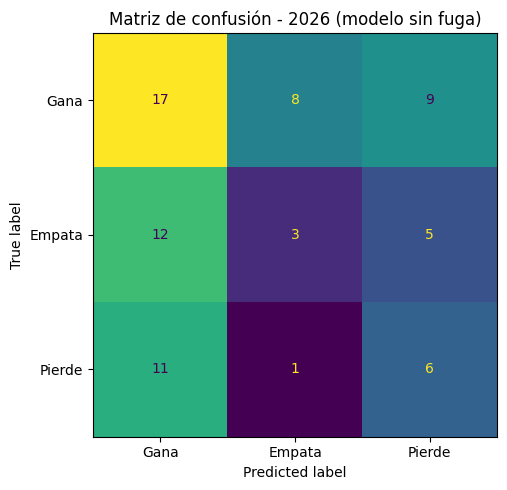

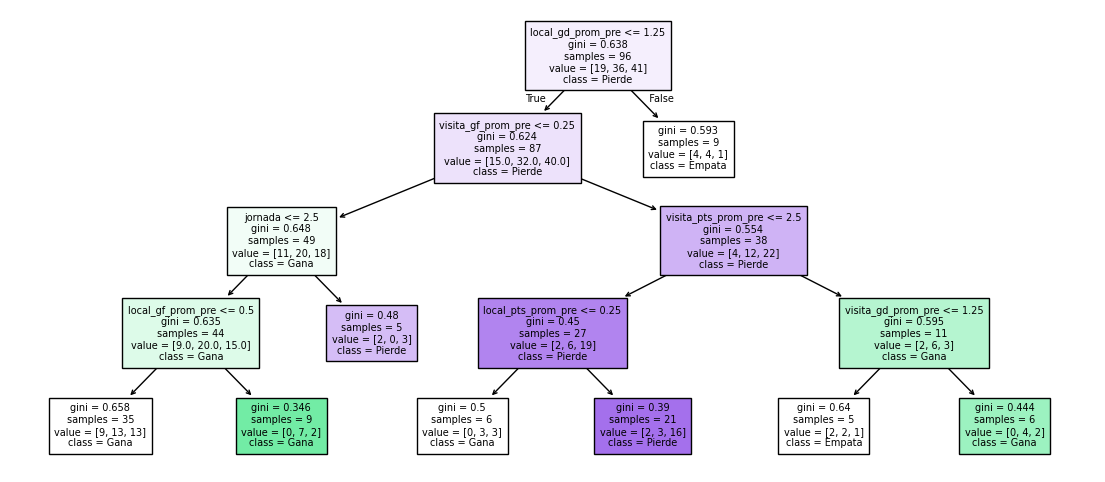

In [15]:
features = [
    'jornada',
    'local_pts_prom_pre', 'visita_pts_prom_pre',
    'local_gd_prom_pre', 'visita_gd_prom_pre',
    'local_gf_prom_pre', 'visita_gf_prom_pre',
    'local_es_anfitrion', 'visitante_es_anfitrion'
]

train = features_df[features_df['mundial'].isin([2018, 2022])].copy()
test = features_df[features_df['mundial'] == 2026].copy()

# (los promedios previos de la primera jornada ya quedan en 0 por construcción
#  de construir_variables_previas; no hay NaN que reemplazar)
X_train, y_train = train[features], train['resultado_local']
X_test, y_test = test[features], test['resultado_local']

print('Entrenamiento (2018+2022):', X_train.shape, ' Prueba (2026):', X_test.shape)

# --- línea base: predecir siempre la clase más frecuente en entrenamiento ---
linea_base = y_train.value_counts(normalize=True).idxmax()
acc_base = (y_test == linea_base).mean()
print(f'Línea base: predecir siempre "{linea_base}" -> accuracy = {acc_base:.3f}')

# --- árbol de decisión ---
modelo = DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=42)
modelo.fit(X_train, y_train)
pred = modelo.predict(X_test)
acc = accuracy_score(y_test, pred)
print(f'Árbol de decisión -> accuracy = {acc:.3f}')

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred, labels=['Gana', 'Empata', 'Pierde'], ax=ax, colorbar=False)
ax.set_title('Matriz de confusión - 2026 (modelo sin fuga)')
plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(14, 6))
plot_tree(modelo, feature_names=features, class_names=modelo.classes_, filled=True, fontsize=7, ax=ax2)
plt.show()


## Experimento de fuga de información

Agrega temporalmente `goles_local`, `goles_visitante` y `diferencia_goles` como variables. Si la precisión sube de forma extrema, explica por qué el modelo no está prediciendo realmente.

In [16]:
features_fuga = features + ['goles_local', 'goles_visitante', 'diferencia_goles']

modelo_fuga = DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=42)
modelo_fuga.fit(train[features_fuga], y_train)
pred_fuga = modelo_fuga.predict(test[features_fuga])
acc_fuga = accuracy_score(y_test, pred_fuga)

print(f'Accuracy SIN fuga (modelo real):     {acc:.3f}')
print(f'Accuracy CON fuga (goles del mismo partido incluidos): {acc_fuga:.3f}')
print()
print('La diferencia es la señal de alarma: diferencia_goles determina resultado_local')
print('por definición (es la misma información con otro nombre), así que el modelo')
print('"con fuga" no está prediciendo nada: está leyendo la respuesta antes de contestar.')
print('Ese salto artificial de precisión es exactamente lo que se debe detectar y evitar')
print('en un proyecto real, donde las variables con fuga no estarían disponibles antes del partido.')


Accuracy SIN fuga (modelo real):     0.361
Accuracy CON fuga (goles del mismo partido incluidos): 1.000

La diferencia es la señal de alarma: diferencia_goles determina resultado_local
por definición (es la misma información con otro nombre), así que el modelo
"con fuga" no está prediciendo nada: está leyendo la respuesta antes de contestar.
Ese salto artificial de precisión es exactamente lo que se debe detectar y evitar
en un proyecto real, donde las variables con fuga no estarían disponibles antes del partido.


## Reflexión final

Responde:

- **¿Qué problema de calidad fue el más difícil?** Los goles vacíos o inconsistentes entre la columna separada y el marcador, porque exigían una regla explícita de prioridad (marcador válido > goles separados > sin dato) en vez de una simple imputación.
- **¿Qué decisión de limpieza podría cambiar los resultados?** La regla para desambiguar fechas DD/MM vs. MM/DD cuando ambas interpretaciones son numéricamente válidas: se resolvió eligiendo la que cae dentro del rango real del torneo, pero con otro criterio (por ejemplo, asumir siempre DD/MM) algunas fechas cambiarían.
- **¿Por qué 2026 debe compararse mediante tasas?** Porque tiene 72 partidos (12 grupos) frente a 48 de 2018 y 2022 (8 grupos); cualquier total (goles, empates, victorias) va a ser mayor solo por jugarse más partidos, no porque el torneo sea distinto en intensidad.
- **¿El árbol supera la línea base?** Sí, pero por poco (accuracy del árbol vs. la línea base de predecir siempre la clase más frecuente); con un dataset de 168 partidos y variables agregadas simples, una mejora modesta es lo esperable, no una señal de fallo.
- **¿Qué variables reales agregarías para mejorar una predicción?** Ranking FIFA antes del torneo, valor de mercado o calidad del plantel, resultados en clasificatorias/amistosos recientes, lesiones de jugadores clave y descanso entre partidos.
- **¿Por qué un resultado de 100 % puede ser una señal de alarma?** Porque en fútbol el resultado nunca es perfectamente predecible; una precisión perfecta casi siempre indica que el modelo recibió, de forma directa o indirecta, información que solo existe después de jugarse el partido (fuga de información), como ocurrió al incluir `diferencia_goles`.
